In [1]:
from attention_motifs.dataset.dataset import (
	APGenerationConfig,
	PromptDatasetConfig,
	CollectedAttentionPatternDataloader,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
d = CollectedAttentionPatternDataloader.generate(
	config=APGenerationConfig(
		prompts_config=PromptDatasetConfig.from_source_path(
			"../data/pile_50.jsonl",
			char_len_min=64,
			char_len_max=256,
		),
		model_names=[
			"pythia-14m",
			"gpt2-small",
			"meta-llama/Llama-3.2-1B",
		],
		token_len_min=16,
		prompt_token_len_tolerance=16,
	),
	max_batch_size=8,
)

# Processing model: pythia-14m
--------------------------------------------------
\ (20.19s) Loading model pythia-14m                                            

The `GPTNeoXSdpaAttention` class is deprecated in favor of simply modifying the `config._attn_implementation`attribute of the `GPTNeoXAttention` class! It will be removed in v4.48


/ (41.25s) Loading model pythia-14m                                            Loaded pretrained model pythia-14m into HookedTransformer
# (41.34s) Loading model pythia-14m                                            
#	loaded pythia-14m with 1179648 (1.2M) parameters
#	model devices: {device(type='cuda', index=0)}
# (0.39s) tokenizing and binning prompts                                       
#	shapes of each bin contents (n_seqs, n_ctx): [ (132, 64), (372, 48), (17, 80), (58, 32), (17, 16), (3, 96) ]
# getting attention patterns:


n_ctx = 96: 100%|██████████| 599/599 [00:03<00:00, 162Seq/s]

# Processing model: gpt2-small
--------------------------------------------------
/ (0.10s) Loading model gpt2-small                                             

...

- (33.61s) Loading model meta-llama/Llama-3.2-1B                               

\ (43.99s) Loading model meta-llama/Llama-3.2-1B                               Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
# (44.09s) Loading model meta-llama/Llama-3.2-1B                               
#	loaded meta-llama/Llama-3.2-1B with 1073741824 (1.1B) parameters
#	model devices: {device(type='cuda', index=0)}
# (0.43s) tokenizing and binning prompts                                       
#	shapes of each bin contents (n_seqs, n_ctx): [ (61, 64), (446, 48), (67, 32), (17, 16), (1, 96), (6, 80) ]
# getting attention patterns:


n_ctx = 80: 100%|██████████| 598/598 [07:20<00:00, 1.36Seq/s] 

/ (0.10s) assembling datasets                                                  

# (2.22s) assembling datasets                                                  
# done generating datasets! summary:
--------------------------------------------------
{
  "n_total_samples": 406808,
  "n_prompts": 599,
  "n_datasets": 9,
  "config": {
    "prompts_config": {
      "name": "pile_50",
      "source_path": "../data/pile_50.jsonl",
      "char_len_min": 64,
      "char_len_max": 256
    },
    "model_names": [
      "pythia-14m",
      "gpt2-small",
      "meta-llama/Llama-3.2-1B"
    ],
    "token_len_min": 16,
    "prompt_token_len_tolerance": 16,
    "raw_scores": false
  },
  "dataset_shapes_summary": [
    "(52256, 64, 64)",
    "(289408, 48, 48)",
    "(6648, 80, 80)",
    "(42464, 32, 32)",
    "(11560, 16, 16)",
    "(2024, 96, 96)",
    "(288, 112, 112)",
    "(1872, 128, 128)",
    "(288, 144, 144)"
  ]
}
--------------------------------------------------


In [4]:
import json

print(json.dumps(d.summary()))

{"model_names": ["pythia-14m", "gpt2-small", "meta-llama/Llama-3.2-1B"], "dataset_shapes_summary": ["(52256, 64, 64)", "(289408, 48, 48)", "(6648, 80, 80)", "(42464, 32, 32)", "(11560, 16, 16)", "(2024, 96, 96)", "(288, 112, 112)", "(1872, 128, 128)", "(288, 144, 144)"], "n_datasets": 9, "n_total_samples": 406808, "n_ctx_stats": {"total_items": 406808, "n_keys": 9, "mode": 48, "mean": 48.71896324556056, "std": 12.460334267793039, "min": 16, "q1": 48.0, "median": 48.0, "q3": 48.0, "max": 144}, "config": {"__format__": "APGenerationConfig(SerializableDataclass)", "prompts_config": {"__format__": "PromptDatasetConfig(SerializableDataclass)", "name": "pile_50", "source_path": "../data/pile_50.jsonl", "source_info": {"source_path": "../data/pile_50.jsonl"}, "char_len_min": 64, "char_len_max": 256}, "model_names": ["pythia-14m", "gpt2-small", "meta-llama/Llama-3.2-1B"], "token_len_min": 16, "prompt_token_len_tolerance": 16, "raw_scores": false}, "prompts": {"config": {"__format__": "PromptDa

In [5]:
d.save("../data/activations/medium", verbose=True)

# (0.08s) Saving metadata                                                      
# (0.08s) Saving prompts                                                       


Saving datasets: 100%|██████████| 9/9 [00:48<00:00,  5.36s/dataset]


torch.Size([2, 64, 64])
[AttentionPatternMetadata(model_name='pythia-14m', idx_layer=0, idx_head=0, n_ctx=64, prompt_hash=array([ 494996417, 2792078879], dtype=uint64)), AttentionPatternMetadata(model_name='pythia-14m', idx_layer=0, idx_head=0, n_ctx=64, prompt_hash=array([ 494996417, 2792078879], dtype=uint64))]


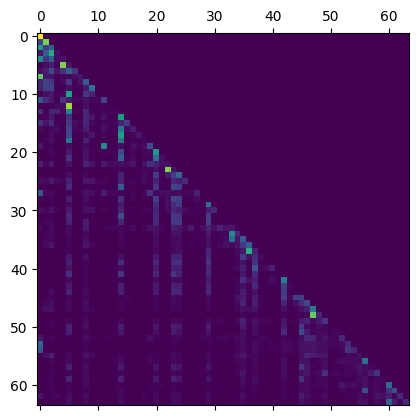

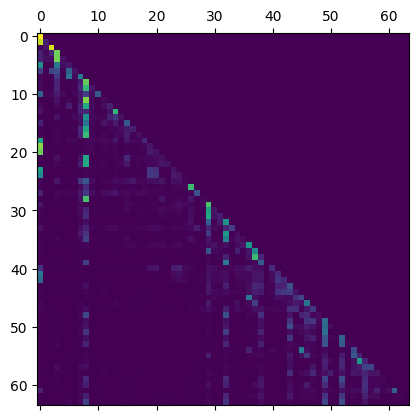

In [6]:
import matplotlib.pyplot as plt

for x in d.batches(2):
	print(x[0].shape)
	print(x[1])
	plt.matshow(x[0][0].cpu().numpy())
	plt.show()
	plt.matshow(x[0][1].cpu().numpy())
	plt.show()
	break